# EDA - Data Análisis de AIRBNB

### Proyecto Grupal — Data Análisis de airbnb en diferentes ciudades ( london, madrid, milan, NY, sydney y tokyo)

---

Antes de empezar, comentar que se han revisado los datasets con excel o programas similares y se ha observado lo siguiente :

- El dataset de *Tokyo* tiene caracteres en japonés -> Habrá que traducirlos a inglés. ?????
- Revisar si las columnas de **latitude** y **longitude** son numéricas.
- La columna **price** tiene precios en diferentes monedas -> unificarlo todo a euros. Los datos de media son del año 2019. Habrá que poner el cambio de moneda de ese año.
- La columna **last_review** contiene fechas -> unificarlo todo para que tengan datos de tipo fecha y en el mismo formato todas (yyy-mm-dd).
- Verificar que la columna **room_type** tiene valores iguales en todos los datasets.
- Crear ua columna nueva llamada **city** con el nombre de la ciudad.
- Antes de fusionar todos los datasets verificar los nombres de las columnas para que sean iguales.

---

## 📖 ¿Qué es un EDA y para qué sirve?

El **Análisis Exploratorio de Datos (EDA)** es el primer paso de todo proyecto.  
Antes de entrenar cualquier modelo, necesitamos **entender** los datos:
- ¿Qué hay en el dataset?
- ¿Los datos están limpios o tienen errores?
- ¿Qué variables son importantes?
- ¿Hay patrones o relaciones entre variables?

**Analogía:** El EDA es como leer el manual de instrucciones antes de montar un mueble. Puedes saltártelo, pero luego te sobran tornillos.

---

## 🗺️ Hoja de Ruta del Notebook

| Sección | Qué vamos a hacer |
|--------|-------------------|
| **1** | Importar librerías y cargar datos |
| **2** | Primera inspección de los datasets y fusión en un único dataset |
| **3** | Inspección del dataset fusionado y Análisis de valores nulos |
| **4** | Análisis de variables numéricas |
| **5** | Análisis de variables categóricas |
| **6** | Correlaciones entre variables |
| **7** | Detección de outliers |
| **8** | Conclusiones |

---

# Sección 1

### Importando librerías

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Leyendo archivos en formato csv de airbnb de diferentes ciudades

#### leyendo archivo de london_airbnb.csv

In [2]:
df_london = pd.read_csv('../data/raw/london_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_london.shape
print(f'✅ Dataset london_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset london_airbnb cargado correctamente
📊 Dimensiones: 85068 filas x 16 columnas


#### leyendo archivo de madrid_airbnb.csv

In [3]:
df_madrid = pd.read_csv('../data/raw/madrid_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_madrid.shape
print(f'✅ Dataset madrid_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset madrid_airbnb cargado correctamente
📊 Dimensiones: 19618 filas x 16 columnas


#### leyendo archivo de milan_airbnb.csv

In [4]:
df_milan = pd.read_csv('../data/raw/milan_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_milan.shape
print(f'✅ Dataset milan_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset milan_airbnb cargado correctamente
📊 Dimensiones: 18322 filas x 15 columnas


#### leyendo archivo de NY_airbnb.csv

In [5]:
df_ny = pd.read_csv('../data/raw/NY_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_ny.shape
print(f'✅ Dataset NY_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset NY_airbnb cargado correctamente
📊 Dimensiones: 48895 filas x 16 columnas


#### leyendo archivo de sydney_airbnb.csv

In [6]:
df_sydney = pd.read_csv('../data/raw/sydney_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_sydney.shape
print(f'✅ Dataset sydney_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset sydney_airbnb cargado correctamente
📊 Dimensiones: 36662 filas x 16 columnas


#### leyendo archivo de tokyo_airbnb.csv

In [7]:
df_tokyo = pd.read_csv('../data/raw/tokyo_airbnb.csv')

# Obtener filas y columnas
filas, columnas = df_tokyo.shape
print(f'✅ Dataset tokyo_airbnb cargado correctamente')
print(f'📊 Dimensiones: {filas} filas x {columnas} columnas')

✅ Dataset tokyo_airbnb cargado correctamente
📊 Dimensiones: 11466 filas x 14 columnas


--- 

# Sección 2

### Primera inspección de los datasets antes de fusionarlos

#### Dataset df_london

In [8]:
# Información general del dataset
print('ℹ️ Información del dataset df_london:')
df_london.info()

ℹ️ Información del dataset df_london:
<class 'pandas.DataFrame'>
RangeIndex: 85068 entries, 0 to 85067
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              85068 non-null  int64  
 1   name                            85042 non-null  str    
 2   host_id                         85068 non-null  int64  
 3   host_name                       85056 non-null  str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   85068 non-null  str    
 6   latitude                        85068 non-null  float64
 7   longitude                       85068 non-null  float64
 8   room_type                       85068 non-null  str    
 9   price                           85068 non-null  int64  
 10  minimum_nights                  85068 non-null  int64  
 11  number_of_reviews               85068 non-null  int64  
 12  last_

---

- Aparece el número de no nulos por columna, el resto son nulos.
- La columna *neighbourhood_group* no contiene datos, es float64 y contiene NaN.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio en libras y hay que convertirlo a euros - 1 euro = 0.877 libras esterlinas en 2019.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.

---

In [9]:
# Número de nulos de la columna neighbourhood_group
df_london['neighbourhood_group'].isna().sum()

np.int64(85068)

In [10]:
# Convertir la columna last_review a tipo fecha
df_london['last_review'] = pd.to_datetime(df_london['last_review'], format='%Y-%m-%d', errors='coerce')
df_london['last_review'].dtype

dtype('<M8[us]')

In [11]:
df_london.info()

<class 'pandas.DataFrame'>
RangeIndex: 85068 entries, 0 to 85067
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              85068 non-null  int64         
 1   name                            85042 non-null  str           
 2   host_id                         85068 non-null  int64         
 3   host_name                       85056 non-null  str           
 4   neighbourhood_group             0 non-null      float64       
 5   neighbourhood                   85068 non-null  str           
 6   latitude                        85068 non-null  float64       
 7   longitude                       85068 non-null  float64       
 8   room_type                       85068 non-null  str           
 9   price                           85068 non-null  int64         
 10  minimum_nights                  85068 non-null  int64         
 11  number_of_rev

In [12]:
# Cambiar el price a euros
df_london['price'] = (df_london['price'] / 0.877).round(2)

In [13]:
# Ver valores únicos de la columna room_type
df_london['room_type'].unique()

<StringArray>
['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']
Length: 4, dtype: str

In [14]:
# Crear la columna city con el nombre de la ciudad
df_london['city'] = 'London'

In [15]:
df_london.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,11551,Arty and Bright London Apartment in Zone 2,43039,Adriano,NaN,Lambeth,51.46225,-0.11732,Entire home/apt,100.34,3,185,2019-09-15,1.58,2,336,London
1,13913,Holiday London DB Room Let-on going,54730,Alina,NaN,Islington,51.56802,-0.11121,Private room,74.12,1,19,2019-10-07,0.17,2,365,London
2,90700,Sunny Notting Hill flat & terrace,491286,Chil,NaN,Kensington and Chelsea,51.51074,-0.19853,Entire home/apt,119.73,2,339,2019-07-30,3.33,2,268,London
3,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,NaN,Kensington and Chelsea,51.48796,-0.16898,Entire home/apt,114.03,30,88,2019-09-23,0.73,1,158,London
4,92399,"MODERN SELF CONTAINED ARCHITECT FLATLET, ISLIN...",497366,Andrea & Mark,NaN,Islington,51.55071,-0.08547,Private room,87.80,1,207,2019-10-21,2.04,2,336,London


In [16]:
df_london.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,8.506800e+04,8.506800e+04,0.0,85068.000000,85068.000000,85068.000000,85068.000000,85068.000000,65062,65062.000000,85068.000000,85068.000000
mean,2.319997e+07,8.514442e+07,NaN,51.509798,-0.128343,139.495103,4.148105,17.471152,2019-03-08 01:56:15.795395,1.201995,22.151150,118.471987
min,1.155100e+04,2.697000e+03,NaN,51.294790,-0.496680,0.000000,1.000000,0.000000,2011-07-02 00:00:00,0.010000,1.000000,0.000000
25%,1.441315e+07,1.529856e+07,NaN,51.485610,-0.188412,53.590000,1.000000,1.000000,2018-12-29 00:00:00,0.250000,1.000000,0.000000
50%,2.363201e+07,4.762387e+07,NaN,51.514015,-0.125725,95.780000,2.000000,4.000000,2019-08-29 00:00:00,0.730000,1.000000,58.000000
75%,3.349281e+07,1.415435e+08,NaN,51.537580,-0.070127,159.640000,3.000000,17.000000,2019-10-18 00:00:00,1.630000,5.000000,244.000000
max,3.988030e+07,3.070013e+08,NaN,51.681690,0.285390,14076.400000,1125.000000,716.000000,2019-11-06 00:00:00,20.130000,999.000000,365.000000
std,1.132475e+07,8.603532e+07,NaN,0.046341,0.093034,251.709348,16.681720,36.789578,NaN,1.402728,110.654631,134.840097


#### Dataset df_madrid

In [17]:
# Información general del dataset
print('ℹ️ Información del dataset df_madrid:')
df_madrid.info()

ℹ️ Información del dataset df_madrid:
<class 'pandas.DataFrame'>
RangeIndex: 19618 entries, 0 to 19617
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              19618 non-null  int64  
 1   name                            19615 non-null  str    
 2   host_id                         19618 non-null  int64  
 3   host_name                       19091 non-null  str    
 4   neighbourhood_group             19618 non-null  str    
 5   neighbourhood                   19618 non-null  str    
 6   latitude                        19618 non-null  float64
 7   longitude                       19618 non-null  float64
 8   room_type                       19618 non-null  str    
 9   price                           19618 non-null  int64  
 10  minimum_nights                  19618 non-null  int64  
 11  number_of_reviews               19618 non-null  int64  
 12  last_

---

- Aparece el número de no nulos por columna, el resto son nulos.
- La columna *neighbourhood_group* es de tipo str.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio y suponemos que es en euros.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.

---

In [18]:
# Convertir la columna last_review a tipo fecha
df_madrid['last_review'] = pd.to_datetime(df_madrid['last_review'], format='%Y-%m-%d', errors='coerce')
df_madrid['last_review'].dtype

dtype('<M8[us]')

In [19]:
df_madrid.info()

<class 'pandas.DataFrame'>
RangeIndex: 19618 entries, 0 to 19617
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              19618 non-null  int64         
 1   name                            19615 non-null  str           
 2   host_id                         19618 non-null  int64         
 3   host_name                       19091 non-null  str           
 4   neighbourhood_group             19618 non-null  str           
 5   neighbourhood                   19618 non-null  str           
 6   latitude                        19618 non-null  float64       
 7   longitude                       19618 non-null  float64       
 8   room_type                       19618 non-null  str           
 9   price                           19618 non-null  int64         
 10  minimum_nights                  19618 non-null  int64         
 11  number_of_rev

In [20]:
# Ver valores únicos de la columna room_type
df_madrid['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room', 'Hotel room']
Length: 4, dtype: str

In [21]:
# Crear la columna city con el nombre de la ciudad
df_madrid['city'] = 'Madrid'

In [22]:
df_madrid.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,6369,"Rooftop terrace room , ensuite bathroom",13660,Simon,Chamartín,Hispanoamérica,40.45724,-3.67688,Private room,60,1,78,2020-09-20,0.58,1,180,Madrid
1,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40381,-3.74130,Private room,31,4,33,2018-07-15,0.42,2,364,Madrid
2,23001,Apartmento Arganzuela- Madrid Rio,82175,Jesus,Arganzuela,Legazpi,40.38840,-3.69511,Entire home/apt,50,15,0,NaT,NaN,7,1,Madrid
3,24805,Gran Via Studio Madrid,346366726,A,Centro,Universidad,40.42183,-3.70529,Entire home/apt,92,5,10,2020-03-01,0.13,1,72,Madrid
4,26825,Single Room whith private Bathroom,114340,Agustina,Arganzuela,Legazpi,40.38975,-3.69018,Private room,26,2,149,2020-03-12,1.12,1,365,Madrid


In [23]:
df_madrid.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,1.961800e+04,1.961800e+04,19618.000000,19618.000000,19618.000000,19618.000000,19618.000000,13981,13981.000000,19618.000000,19618.000000
mean,2.912200e+07,1.312165e+08,40.420984,-3.694040,129.271740,6.586196,31.858803,2020-02-16 23:45:53.365281,1.125958,10.229177,159.098328
min,6.369000e+03,7.952000e+03,40.332210,-3.863910,0.000000,1.000000,0.000000,2012-05-28 00:00:00,0.010000,1.000000,0.000000
25%,1.903424e+07,2.765313e+07,40.409393,-3.707700,35.000000,1.000000,0.000000,2019-10-25 00:00:00,0.170000,1.000000,0.000000
50%,3.187506e+07,9.901898e+07,40.419735,-3.701120,58.000000,2.000000,4.000000,2020-03-08 00:00:00,0.590000,2.000000,126.000000
75%,4.090994e+07,2.256898e+08,40.430290,-3.685420,100.000000,3.000000,31.000000,2021-02-03 00:00:00,1.630000,6.000000,320.000000
max,4.918779e+07,3.964281e+08,40.562740,-3.531900,9999.000000,1125.000000,706.000000,2021-04-17 00:00:00,16.220000,163.000000,365.000000
std,1.351839e+07,1.166790e+08,0.022627,0.028671,484.143545,33.286582,63.938997,NaN,1.348235,23.546472,144.252803


#### Dataset df_milan

In [24]:
# Información general del dataset
print('ℹ️ Información del dataset df_milan:')
df_milan.info()

ℹ️ Información del dataset df_milan:
<class 'pandas.DataFrame'>
RangeIndex: 18322 entries, 0 to 18321
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              18322 non-null  int64  
 1   name                            18312 non-null  str    
 2   host_id                         18322 non-null  int64  
 3   host_name                       18198 non-null  str    
 4   neighbourhood                   18322 non-null  str    
 5   latitude                        18322 non-null  float64
 6   longitude                       18322 non-null  float64
 7   room_type                       18322 non-null  str    
 8   price                           18322 non-null  int64  
 9   minimum_nights                  18322 non-null  int64  
 10  number_of_reviews               18322 non-null  int64  
 11  last_review                     13260 non-null  str    
 12  review

---

- Aparece el número de no nulos por columna, el resto son nulos.
- La columna *neighbourhood_group* No existe en este Dataset.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio y suponemos que es en euros.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.

---

In [25]:
# Convertir la columna last_review a tipo fecha
df_milan['last_review'] = pd.to_datetime(df_milan['last_review'], format='%d/%m/%y', errors='coerce')
df_milan['last_review'].dtype

dtype('<M8[us]')

In [26]:
df_milan.info()

<class 'pandas.DataFrame'>
RangeIndex: 18322 entries, 0 to 18321
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              18322 non-null  int64         
 1   name                            18312 non-null  str           
 2   host_id                         18322 non-null  int64         
 3   host_name                       18198 non-null  str           
 4   neighbourhood                   18322 non-null  str           
 5   latitude                        18322 non-null  float64       
 6   longitude                       18322 non-null  float64       
 7   room_type                       18322 non-null  str           
 8   price                           18322 non-null  int64         
 9   minimum_nights                  18322 non-null  int64         
 10  number_of_reviews               18322 non-null  int64         
 11  last_review  

In [27]:
# Ver valores únicos de la columna room_type
df_milan['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room', 'Hotel room']
Length: 4, dtype: str

In [28]:
# Crear la columna city con el nombre de la ciudad
df_milan['city'] = 'Milan'

In [29]:
df_milan.head(5)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,6400,The Studio Milan,13822,Francesca,TIBALDI,45.44119,9.17813,Private room,100,4,12,2010-04-19,0.14,1,358,Milan
1,23986,""" Characteristic Milanese flat""",95941,Jeremy,NAVIGLI,45.44806,9.17373,Entire home/apt,150,1,15,2020-09-07,0.21,1,363,Milan
2,28300,nice flat near the park,121663,Marta,SARPI,45.47647,9.17359,Private room,180,1,8,2012-04-22,0.11,1,365,Milan
3,32119,Nico & Cynthia's Easy Yellow Suite,138683,Nico&Cinzia,VIALE MONZA,45.52014,9.22300,Entire home/apt,75,2,15,2018-07-01,0.23,3,200,Milan
4,32649,Nico&Cinzia's Red Easy Suite!,138683,Nico&Cinzia,VIALE MONZA,45.51874,9.22495,Entire home/apt,71,2,29,2016-10-23,0.71,3,308,Milan


In [30]:
df_milan.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,1.832200e+04,1.832200e+04,18322.000000,18322.000000,18322.000000,18322.000000,18322.000000,13260,13260.000000,18322.000000,18322.000000
mean,2.587132e+07,8.494918e+07,45.471318,9.187382,115.094913,5.798112,23.720827,2019-04-13 22:06:04.886877,0.799344,14.421897,153.508624
min,6.400000e+03,1.944000e+03,45.395050,9.060680,8.000000,1.000000,0.000000,2010-04-19 00:00:00,0.010000,1.000000,0.000000
25%,1.214067e+07,1.243642e+07,45.454462,9.168782,50.000000,1.000000,0.000000,2018-05-23 00:00:00,0.100000,1.000000,0.000000
50%,2.588718e+07,3.141304e+07,45.470875,9.186291,73.500000,2.000000,3.000000,2019-09-14 12:00:00,0.310000,1.000000,123.000000
75%,3.926758e+07,1.335227e+08,45.486850,9.209680,110.000000,3.000000,19.000000,2020-02-23 00:00:00,0.990000,4.000000,302.000000
max,5.095505e+07,4.117208e+08,45.539850,9.275280,11999.000000,1124.000000,896.000000,2021-07-11 00:00:00,13.710000,314.000000,365.000000
std,1.525744e+07,1.040579e+08,0.020731,0.029543,290.793019,26.687720,57.657486,NaN,1.220346,46.295635,138.757302


#### Dataset df_ny

In [31]:
# Información general del dataset
print('ℹ️ Información del dataset df_ny:')
df_ny.info()

ℹ️ Información del dataset df_ny:
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_revi

---

- Aparece el número de no nulos por columna, el resto son nulos.
- La columna *neighbourhood_group* es de tipo str.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio en dolares y hay que convertirlo a euros - 1 euro = 1.11 dolares USA en 2019.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.

---

In [32]:
# Convertir la columna last_review a tipo fecha
df_ny['last_review'] = pd.to_datetime(df_ny['last_review'], format='%Y-%m-%d', errors='coerce')
df_ny['last_review'].dtype

dtype('<M8[us]')

In [33]:
df_ny.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  str           
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  str           
 4   neighbourhood_group             48895 non-null  str           
 5   neighbourhood                   48895 non-null  str           
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  str           
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  number_of_rev

In [34]:
# Cambiar el price a euros
df_ny['price'] = (df_ny['price'] / 1.11).round(2)

In [35]:
# Ver valores únicos de la columna room_type
df_ny['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [36]:
# Crear la columna city con el nombre de la ciudad
df_ny['city'] = 'New York'

In [37]:
df_ny.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,134.23,1,9,2018-10-19,0.21,6,365,New York
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,202.70,1,45,2019-05-21,0.38,2,355,New York
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,135.14,3,0,NaT,NaN,1,365,New York
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,80.18,1,270,2019-07-05,4.64,1,194,New York
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,72.07,10,9,2018-11-19,0.10,1,0,New York


In [38]:
df_ny.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,137.586684,7.029962,23.274466,2018-10-04 01:47:23.910099,1.373221,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,62.160000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,95.500000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,157.660000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,9009.010000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,216.355145,20.510550,44.550582,NaN,1.680442,32.952519,131.622289


#### Dataset df_sydney

In [39]:
# Información general del dataset
print('ℹ️ Información del dataset df_sydney:')
df_sydney.info()

ℹ️ Información del dataset df_sydney:
<class 'pandas.DataFrame'>
RangeIndex: 36662 entries, 0 to 36661
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              36662 non-null  int64  
 1   name                            36650 non-null  str    
 2   host_id                         36662 non-null  int64  
 3   host_name                       36656 non-null  str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   36662 non-null  str    
 6   latitude                        36662 non-null  float64
 7   longitude                       36662 non-null  float64
 8   room_type                       36662 non-null  str    
 9   price                           36662 non-null  int64  
 10  minimum_nights                  36662 non-null  int64  
 11  number_of_reviews               36662 non-null  int64  
 12  last_

---

- Aparece el número de no nulos por columna, el resto son nulos.
- La columna *neighbourhood_group* no contiene datos, es float64 y contiene NaN.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio en dolares australianos AUD y hay que convertirlo a euros - 1 euro = 1.61 dolares Australianos en 2019.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.

---

In [40]:
# Convertir la columna last_review a tipo fecha
df_sydney['last_review'] = pd.to_datetime(df_sydney['last_review'], format='%Y-%m-%d', errors='coerce')
df_sydney['last_review'].dtype

dtype('<M8[us]')

In [41]:
df_sydney.info()

<class 'pandas.DataFrame'>
RangeIndex: 36662 entries, 0 to 36661
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              36662 non-null  int64         
 1   name                            36650 non-null  str           
 2   host_id                         36662 non-null  int64         
 3   host_name                       36656 non-null  str           
 4   neighbourhood_group             0 non-null      float64       
 5   neighbourhood                   36662 non-null  str           
 6   latitude                        36662 non-null  float64       
 7   longitude                       36662 non-null  float64       
 8   room_type                       36662 non-null  str           
 9   price                           36662 non-null  int64         
 10  minimum_nights                  36662 non-null  int64         
 11  number_of_rev

In [42]:
# Cambiar el price a euros
df_sydney['price'] = (df_sydney['price'] / 1.61).round(2)

In [43]:
# Ver valores únicos de la columna room_type
df_sydney['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [44]:
# Crear la columna city con el nombre de la ciudad
df_sydney['city'] = 'Sydney'

In [45]:
df_sydney.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,12351,Sydney City & Harbour at the door,17061,Stuart,NaN,Sydney,-33.865153,151.191896,Private room,62.11,2,493,2018-11-21,4.83,2,187,Sydney
1,14250,Manly Harbour House,55948,Heidi,NaN,Manly,-33.800929,151.261722,Entire home/apt,292.55,5,1,2016-01-02,0.03,2,321,Sydney
2,15253,Stunning Penthouse Apartment In Heart Of The City,59850,Morag,NaN,Sydney,-33.880455,151.216541,Private room,67.70,2,300,2018-11-16,3.63,2,316,Sydney
3,20865,3 BED HOUSE + 1 BED STUDIO Balmain,64282,Fiona,NaN,Leichhardt,-33.859072,151.172753,Entire home/apt,279.50,7,15,2018-01-07,0.18,1,69,Sydney
4,26174,"COZY PRIVATE ROOM, GREAT LOCATION!",110561,Amanda,NaN,Woollahra,-33.889087,151.259404,Private room,38.51,1,42,2018-11-23,0.45,1,140,Sydney


In [46]:
df_sydney.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,3.666200e+04,3.666200e+04,0.0,36662.000000,36662.000000,36662.000000,36662.000000,36662.000000,24725,24725.000000,36662.000000,36662.000000
mean,1.852083e+07,6.561620e+07,NaN,-33.863112,151.204259,128.999501,5.096885,12.185178,2018-03-16 12:12:15.579373,1.139057,7.115106,97.387595
min,1.235100e+04,8.346000e+03,NaN,-34.135212,150.642903,0.000000,1.000000,0.000000,2011-11-25 00:00:00,0.010000,1.000000,0.000000
25%,1.170461e+07,1.506022e+07,NaN,-33.898444,151.179678,49.690000,1.000000,0.000000,2017-12-30 00:00:00,0.140000,1.000000,0.000000
50%,2.027350e+07,4.134819e+07,NaN,-33.882486,151.215923,84.470000,2.000000,2.000000,2018-08-21 00:00:00,0.490000,1.000000,36.000000
75%,2.524405e+07,1.053605e+08,NaN,-33.832072,151.261413,138.510000,5.000000,9.000000,2018-11-19 00:00:00,1.520000,2.000000,165.000000
max,3.059387e+07,2.294790e+08,NaN,-33.389728,151.339811,9316.150000,1000.000000,493.000000,2018-12-07 00:00:00,15.180000,197.000000,365.000000
std,8.473884e+06,6.374533e+07,NaN,0.071501,0.083529,201.129828,15.664862,28.652548,NaN,1.536521,24.611284,122.969054


#### Dataset df_tokyo

In [47]:
# Información general del dataset
print('ℹ️ Información del dataset df_tokyo:')
df_tokyo.info()

ℹ️ Información del dataset df_tokyo:
<class 'pandas.DataFrame'>
RangeIndex: 11466 entries, 0 to 11465
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   11466 non-null  int64  
 1   name                 11466 non-null  str    
 2   host_id              11466 non-null  int64  
 3   host_name            11450 non-null  str    
 4   neighbourhood_group  0 non-null      float64
 5   neighbourhood        11466 non-null  str    
 6   latitude             11466 non-null  float64
 7   longitude            11466 non-null  float64
 8   room_type            11466 non-null  str    
 9   price                11466 non-null  int64  
 10  minimum_nights       11466 non-null  int64  
 11  number_of_reviews    11466 non-null  int64  
 12  last_review          9789 non-null   str    
 13  reviews_per_month    9789 non-null   float64
dtypes: float64(4), int64(5), str(5)
memory usage: 1.2 MB


---

- Aparece el número de no nulos por columna, el resto son nulos.
- La columna *neighbourhood_group* no contiene datos, es float64 y contiene NaN.
- Las columnas *latitude* y *longitude* son numéricas.
- La columna *price* contiene el precio en yenes JPY y hay que convertirlo a euros - 1 euro = 122 yenes JPY en 2019.
- La columna last_review es de tipo str pero contiene fechas y debe ser de tipo date y en formato yyyy-mm-dd.
- Generamos una nueva columna *calculated_host_listings_count* que no existe en este DataFrame pero si en los demás con el número de propiedades por host_id.
- Generamos una nueva columna *availability_365* que no existe en este DataFrame pero si en los demás con el valor 180.
    - La ley minpaku en Japón obliga a como máximo alquilar el piso en Airbnb 180 días.

---

In [48]:
# Convertir la columna last_review a tipo fecha
df_tokyo['last_review'] = pd.to_datetime(df_tokyo['last_review'], format='%Y-%m-%d', errors='coerce')
df_tokyo['last_review'].dtype

dtype('<M8[us]')

In [49]:
df_tokyo.info()

<class 'pandas.DataFrame'>
RangeIndex: 11466 entries, 0 to 11465
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   11466 non-null  int64         
 1   name                 11466 non-null  str           
 2   host_id              11466 non-null  int64         
 3   host_name            11450 non-null  str           
 4   neighbourhood_group  0 non-null      float64       
 5   neighbourhood        11466 non-null  str           
 6   latitude             11466 non-null  float64       
 7   longitude            11466 non-null  float64       
 8   room_type            11466 non-null  str           
 9   price                11466 non-null  int64         
 10  minimum_nights       11466 non-null  int64         
 11  number_of_reviews    11466 non-null  int64         
 12  last_review          9789 non-null   datetime64[us]
 13  reviews_per_month    9789 non-null   float

In [50]:
# Cambiar el price a euros
df_tokyo['price'] = (df_tokyo['price'] / 122).round(2)

In [51]:
# Ver valores únicos de la columna room_type
df_tokyo['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [52]:
# Calcular frecuencia de 'host_id' y crear la columna 'calculated_host_listings_count'
df_tokyo['calculated_host_listings_count'] = df_tokyo.groupby('host_id')['host_id'].transform('count')

In [53]:
# Crear la columna 'availability_365' con el valor 180
df_tokyo['availability_365'] = 180

In [54]:
# Crear la columna city con el nombre de la ciudad
df_tokyo['city'] = 'Tokyo'

In [55]:
df_tokyo.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,35303,"La Casa Gaienmae C Harajuku, Omotesando is nearby",151977,Miyuki,NaN,Shibuya Ku,35.67152,139.71203,Private room,34.39,28,18,2018-07-28,0.20,3,180,Tokyo
1,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,NaN,Sumida Ku,35.71721,139.82596,Entire home/apt,89.96,3,156,2019-05-21,1.65,1,180,Tokyo
2,289597,Private apt in central Tokyo #203,341577,Hide&Kei,NaN,Nerima Ku,35.74267,139.65810,Entire home/apt,34.39,30,107,2019-05-25,1.25,2,180,Tokyo
3,370759,"Cozy flat #203, local area YET 10 mins to shib...",1573631,"Gilles,Mayumi,Taiki",NaN,Setagaya Ku,35.66344,139.65593,Entire home/apt,57.33,29,99,2019-05-07,1.55,3,180,Tokyo
4,700253,Private apt in central Tokyo #201,341577,Hide&Kei,NaN,Nerima Ku,35.74264,139.65832,Entire home/apt,32.63,30,101,2019-05-03,1.24,2,180,Tokyo


In [56]:
df_tokyo.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,1.146600e+04,1.146600e+04,0.0,11466.000000,11466.000000,11466.000000,11466.000000,11466.000000,9789,9789.000000,11466.000000,11466.0
mean,2.640545e+07,1.399776e+08,NaN,35.687159,139.734537,122.825074,3.316239,26.028868,2019-05-12 19:03:52.791909,2.262540,13.587650,180.0
min,3.530300e+04,1.519770e+05,NaN,27.072330,139.130020,0.000000,1.000000,0.000000,2015-05-25 00:00:00,0.040000,1.000000,180.0
25%,2.215251e+07,5.783171e+07,NaN,35.679620,139.698975,49.390000,1.000000,2.000000,2019-05-14 00:00:00,1.000000,3.000000,180.0
50%,2.841873e+07,1.502326e+08,NaN,35.701910,139.729165,82.020000,1.000000,12.000000,2019-06-08 00:00:00,2.060000,8.000000,180.0
75%,3.222416e+07,2.135896e+08,NaN,35.724215,139.784270,141.110000,2.000000,32.000000,2019-06-17 00:00:00,3.170000,16.000000,180.0
max,3.608660e+07,2.714130e+08,NaN,35.832430,142.202880,8197.100000,180.000000,453.000000,2019-06-27 00:00:00,51.210000,133.000000,180.0
std,7.565212e+06,8.064289e+07,NaN,0.217853,0.092771,272.733223,7.766766,38.455449,NaN,1.744004,19.491406,0.0


### Vamos a fusionar los 6 Datasets

In [57]:
# Apilar los DataFrames verticalmente
df_all = pd.concat([df_london, df_madrid, df_milan, df_ny, df_sydney , df_tokyo], axis=0)

In [58]:
df_all.sample(15)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
8032,6187204,Chinatown/Lower East Side Room,32092775,Jess,Manhattan,Chinatown,40.71546,-73.99226,Private room,67.57,4,23,2018-11-18,0.45,1,212,New York
3643,15442540,"Objetivamente, el mejor apartamento de Madrid.",61695112,María Dolores,Centro,Embajadores,40.41176,-3.69950,Entire home/apt,90.00,6,105,2021-04-12,2.26,2,306,Madrid
71397,36274065,247.2 Hoxton Holiday Relaxing Stay 2 Guests,13557337,Kindle Assets,NaN,Hackney,51.53226,-0.07287,Private room,41.05,1,0,NaT,NaN,173,365,London
46432,25436417,2 Bedroom Flat in Hammersmith,42522818,Helen,NaN,Hammersmith and Fulham,51.49808,-0.22699,Entire home/apt,144.81,3,6,2019-10-27,0.38,3,0,London
12888,37106780,estudio completo pasar un fin de semana en madrid,276620049,Ricardo,Centro,Justicia,40.42263,-3.69965,Entire home/apt,55.00,1,31,2020-03-08,1.48,2,106,Madrid
6913,20168800,Camera condivisa a Primaticcio - Bande Nere.,88723896,Giorgio,NaN,BANDE NERE,45.45167,9.13623,Shared room,15.00,2,2,2017-08-24,0.06,1,0,Milan
209,55467,Private Garden Apt • New Renovation,260709,Paul,Brooklyn,Williamsburg,40.71625,-73.93845,Entire home/apt,126.13,2,253,2019-07-02,3.04,1,125,New York
12766,35366664,CASA VACANZE ROBY,33655230,Luca,NaN,LAMBRATE,45.48377,9.24143,Entire home/apt,39.00,1,46,2019-07-29,1.82,1,123,Milan
14074,10769752,Brooklyn Bright Room Prospect Park w AirCon.,51372003,Ninell,Brooklyn,East Flatbush,40.65058,-73.94859,Private room,48.65,2,63,2018-12-09,1.52,2,316,New York
352,868679,Suitelowcost Corso Venezia,4571936,Manuele,NaN,DUOMO,45.46848,9.19920,Entire home/apt,207.00,1,32,2019-06-15,0.32,9,179,Milan


--- 

# Sección 3

### Inspección del Dataset

**Objetivo:** Entender qué hay dentro del dataset sin entrar en detalles todavía.  
Es como abrir una caja y ver qué hay dentro antes de sacar nada.

**Preguntas que vamos a responder:**
- ¿Cuántas filas y columnas tiene?
- ¿Qué significa cada columna?
- ¿Qué tipo de dato tiene cada columna (número, texto, fecha)?

In [59]:
# Obtener filas y columnas
filas, columnas = df_all.shape
print(f'📊 Dimensiones del Dataset df_all : {filas} filas x {columnas} columnas')

📊 Dimensiones del Dataset df_all : 220031 filas x 17 columnas


In [60]:
# Ver las primeras 5 filas del dataset (head)
# Esto nos da una idea visual de cómo están organizados los datos
df_all.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city
0,11551,Arty and Bright London Apartment in Zone 2,43039,Adriano,NaN,Lambeth,51.46225,-0.11732,Entire home/apt,100.34,3,185,2019-09-15,1.58,2,336,London
1,13913,Holiday London DB Room Let-on going,54730,Alina,NaN,Islington,51.56802,-0.11121,Private room,74.12,1,19,2019-10-07,0.17,2,365,London
2,90700,Sunny Notting Hill flat & terrace,491286,Chil,NaN,Kensington and Chelsea,51.51074,-0.19853,Entire home/apt,119.73,2,339,2019-07-30,3.33,2,268,London
3,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,NaN,Kensington and Chelsea,51.48796,-0.16898,Entire home/apt,114.03,30,88,2019-09-23,0.73,1,158,London
4,92399,"MODERN SELF CONTAINED ARCHITECT FLATLET, ISLIN...",497366,Andrea & Mark,NaN,Islington,51.55071,-0.08547,Private room,87.80,1,207,2019-10-21,2.04,2,336,London


In [61]:
# Información general del dataset
# 'object' = texto | 'float64/int64' = número
print('ℹ️ Información del dataset:')
df_all.info()

ℹ️ Información del dataset:
<class 'pandas.DataFrame'>
Index: 220031 entries, 0 to 11465
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              220031 non-null  int64         
 1   name                            219964 non-null  str           
 2   host_id                         220031 non-null  int64         
 3   host_name                       219325 non-null  str           
 4   neighbourhood_group             68513 non-null   object        
 5   neighbourhood                   220031 non-null  str           
 6   latitude                        220031 non-null  float64       
 7   longitude                       220031 non-null  float64       
 8   room_type                       220031 non-null  str           
 9   price                           220031 non-null  float64       
 10  minimum_nights                  220031 non-nu

In [62]:
# Estadísticas descriptivas de las columnas numéricas (describe)
# count=cuántos valores hay | mean=promedio | std=dispersión | min/max=extremos
df_all.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,2.200310e+05,2.200310e+05,220031.000000,220031.000000,220031.000000,220031.000000,220031.000000,165660,165660.000000,220031.000000,220031.000000
mean,2.240831e+07,8.494528e+07,32.573053,16.428135,133.510207,5.258023,20.129164,2019-01-13 13:00:32.075335,1.256772,14.158110,123.440324
min,2.539000e+03,1.944000e+03,-34.135212,-74.244420,0.000000,1.000000,0.000000,2010-04-19 00:00:00,0.010000,1.000000,0.000000
25%,1.338370e+07,1.439602e+07,40.412620,-3.705870,51.310000,1.000000,1.000000,2018-08-27 00:00:00,0.200000,1.000000,0.000000
50%,2.249789e+07,4.640392e+07,40.794240,-0.128380,86.960000,2.000000,4.000000,2019-06-08 00:00:00,0.690000,1.000000,77.000000
75%,3.155445e+07,1.415097e+08,51.496200,9.199535,147.090000,4.000000,19.000000,2019-10-01 00:00:00,1.800000,4.000000,225.000000
max,5.095505e+07,4.117208e+08,51.681690,151.339811,14076.400000,1250.000000,896.000000,2021-07-11 00:00:00,58.500000,999.000000,365.000000
std,1.175490e+07,8.856607e+07,30.144854,76.030471,271.124286,20.118261,43.012277,NaN,1.524449,73.274143,131.758407


In [63]:
# Ver el nombre de todas las columnas disponibles
df_all.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'city'],
      dtype='str')

## Significado de las columnas

---

- id : Es un identificador, es el identificador de la habitación -> int64
- name : Datos diversos de tipo de habitación. Es el nombre del anuncio -> str
- host_id : Identificador del propietario -> int 64
- host_name : Nombre del propietario -> str
- neighbourhood_group : Distrito de la ciudad -> str
- neighbourhood : Barrio de la ciudad -> str
- latitude : Latitud -> float64
- longitude : Longitud -> float64
- room_type : Tipo de habitación -> str
- price : Precio por noche -> float64
- minimum_nights : Número mínimo de noches a alquilar -> int64
- number_of_reviews : Número de reviews -> int64
- last_review : Fecha de la última review -> datetime64[us]
- reviews_per_month : Número de reviews por mes -> float64
- calculated_host_listings_count : Número de propiedades de un propietario -> float64
- availability_365 : Número de días disponible la habitación -> float64
- city : Ciudad -> str

---

## Informe

---

- La columna *name* es de tipo str y contiene características del apartamento, algunas filas contienen texto en japonés.
- La columna *host_name* de tipo str contiene el nombre del propietario. Algunas filas tienen texto en japonés.
- La columna *neighbourhood_group* es de tipo object y contiene NaN porque algunas ciudades no tenían datos aquí. Contiene la zona de la ciudad.
- La columna *last_review* es de tipo datetime64[us] y está en formato yyyy-mm-dd. Faltan muchas filas.
- La columna *reviews_per_month* es de tipo float y faltan muchas filas.

---

### Análisis del Dataset

#### Análisis de valores nulos

**¿Qué es un valor nulo?**  
Un valor nulo (NaN = Not a Number) es una celda vacía en nuestros datos.  
Ocurre cuando la información no estaba disponible o no se registró.

**¿Por qué importa?**  
Los modelos de ML no pueden trabajar con valores vacíos. Tenemos que decidir qué hacer con ellos:  
- **Eliminar** la fila o columna  
- **Rellenar** con un valor (media, mediana, moda)

**Regla general:**  
- Si una columna tiene `> 40% nulos` → considerar eliminarla  
- Si tiene `< 40% nulos` → rellenar (imputar)

In [64]:
# Contar valores nulos por columna (isnull().sum())
df_all.isnull().sum()

id                                     0
name                                  67
host_id                                0
host_name                            706
neighbourhood_group               151518
neighbourhood                          0
latitude                               0
longitude                              0
room_type                              0
price                                  0
minimum_nights                         0
number_of_reviews                      0
last_review                        54371
reviews_per_month                  54371
calculated_host_listings_count         0
availability_365                       0
city                                   0
dtype: int64

In [65]:
# Muestra el porcentaje de nulos por columna
porcentaje_nulos = df_all.isnull().mean() * 100
print(porcentaje_nulos)

id                                 0.000000
name                               0.030450
host_id                            0.000000
host_name                          0.320864
neighbourhood_group               68.862115
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       24.710609
reviews_per_month                 24.710609
calculated_host_listings_count     0.000000
availability_365                   0.000000
city                               0.000000
dtype: float64


#### Vamos a borrar las 706 filas sin host_name

In [66]:
# Para borrar en el DataFrame directamente
df_all.dropna(subset=['host_name'], inplace=True)

In [67]:
# Ver el número de nan en la columna 'host_name'
df_all['host_name'].isna().sum()

np.int64(0)

#### Vamos a poner los valores NaN de la columna *neighbourhood_group* a "Unknown"

In [68]:
# Reemplazar nulos en la columna 'neighbourhood_group' por 'Unknown'
df_all['neighbourhood_group'] = df_all['neighbourhood_group'].fillna('Unknown')
# Comprobamos el cambio
df_all['neighbourhood_group'].unique()

array(['Unknown', 'Chamartín', 'Latina', 'Arganzuela', 'Centro',
       'Salamanca', 'Fuencarral - El Pardo', 'Puente de Vallecas',
       'Ciudad Lineal', 'Chamberí', 'Villaverde', 'Hortaleza',
       'Moncloa - Aravaca', 'Carabanchel', 'Tetuán', 'Retiro',
       'San Blas - Canillejas', 'Villa de Vallecas', 'Barajas', 'Usera',
       'Vicálvaro', 'Moratalaz', 'Brooklyn', 'Manhattan', 'Queens',
       'Staten Island', 'Bronx'], dtype=object)

In [69]:
# Covertir la columna *neighbourhood_group* a str
df_all['neighbourhood_group'] = df_all['neighbourhood_group'].astype(str)

#### Rellenamos las faltantes de *reviews_per_month* con el valor **0**

In [70]:
# Rellenamos las faltantes de reviews_per_month con el valor 0
df_all['reviews_per_month'] = df_all['reviews_per_month'].fillna(0)

In [71]:
# Ver el número de nan en la columna 'reviews_per_month'
df_all['reviews_per_month'].isna().sum()

np.int64(0)

#### Ver como queda el DataFrame después de los cambios

In [72]:
df_all.info()

<class 'pandas.DataFrame'>
Index: 219325 entries, 0 to 11465
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              219325 non-null  int64         
 1   name                            219258 non-null  str           
 2   host_id                         219325 non-null  int64         
 3   host_name                       219325 non-null  str           
 4   neighbourhood_group             219325 non-null  str           
 5   neighbourhood                   219325 non-null  str           
 6   latitude                        219325 non-null  float64       
 7   longitude                       219325 non-null  float64       
 8   room_type                       219325 non-null  str           
 9   price                           219325 non-null  float64       
 10  minimum_nights                  219325 non-null  int64         
 11  numb

In [73]:
df_all.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,2.193250e+05,2.193250e+05,219325.000000,219325.000000,219325.000000,219325.000000,219325.000000,165229,219325.000000,219325.000000,219325.000000
mean,2.237962e+07,8.477555e+07,32.546667,16.477441,133.161689,5.262118,20.111437,2019-01-12 14:47:58.840881,0.946845,14.130642,123.262473
min,2.539000e+03,1.944000e+03,-34.135212,-74.244420,0.000000,1.000000,0.000000,2010-04-19 00:00:00,0.000000,1.000000,0.000000
25%,1.337142e+07,1.435334e+07,40.412630,-3.705930,51.310000,1.000000,1.000000,2018-08-27 00:00:00,0.020000,1.000000,0.000000
50%,2.247996e+07,4.627374e+07,40.795840,-0.127810,87.000000,2.000000,4.000000,2019-06-08 00:00:00,0.320000,1.000000,76.000000
75%,3.150030e+07,1.409756e+08,51.496410,9.200150,147.090000,4.000000,19.000000,2019-09-30 00:00:00,1.290000,4.000000,224.000000
max,5.095505e+07,4.117208e+08,51.681690,151.339811,14076.400000,1250.000000,896.000000,2021-07-11 00:00:00,58.500000,999.000000,365.000000
std,1.173236e+07,8.845968e+07,30.186867,76.130359,267.686055,20.137939,42.996240,NaN,1.430171,73.347726,131.675499


### Mapa de calor

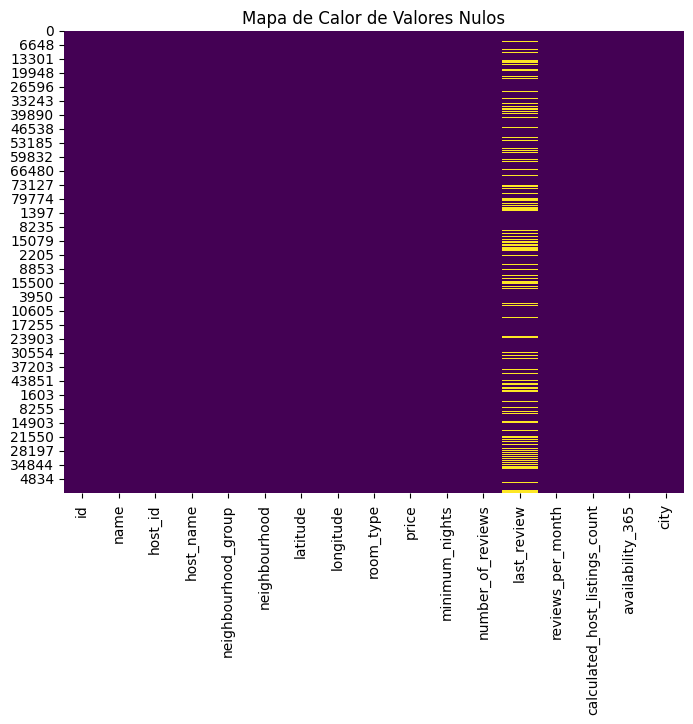

In [74]:
# Visualizar los nulos con un heatmap
# Visualizar nulos
plt.figure(figsize=(8, 6))
sns.heatmap(df_all.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de Calor de Valores Nulos")
plt.show()

# Decidir que columnas eliminar

### Columnas a borrar : *name*

In [75]:
df_all.drop(['name'], axis=1, inplace=True)

#### Dejamos la columna *last_review* como está aunque tenga muchos nulos.

In [76]:
# Tipos nulos de datos DateTime de columna 'last_review'
df_all['last_review'].isnull().sum()

np.int64(54096)

#### Generamos una nueva columna 'host_type' que contendrá el tipo de propietario que gestiona el piso.
- Si tiene más de 3 pisos será *superhost' y sino 'host'

In [77]:
df_all['host_type'] = np.where(df_all['calculated_host_listings_count'] > 3, 'superhost', 'host')

In [78]:
df_all.sample(5)

,id,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,city,host_type
7884,26416620,189499794,Moha,Centro,Sol,40.41822,-3.70647,Private room,25.00,3,18,2019-08-27,0.53,26,0,Madrid,superhost
9570,7347350,6284410,Fiona,Brooklyn,Williamsburg,40.70794,-73.93976,Private room,31.53,5,1,2016-07-21,0.03,1,0,New York,host
11008,8504666,44782700,Danielle,Brooklyn,Bedford-Stuyvesant,40.68426,-73.91939,Entire home/apt,180.18,3,63,2019-06-13,1.39,1,354,New York,host
53761,28910824,55288809,Yasemin,Unknown,Wandsworth,51.45180,-0.21970,Private room,57.01,1,19,2019-10-13,1.53,1,356,London,host
12489,9609246,49720830,Sarah,Manhattan,Murray Hill,40.74899,-73.97301,Private room,107.21,1,1,2015-12-31,0.02,1,0,New York,host


--- 

# Sección 4

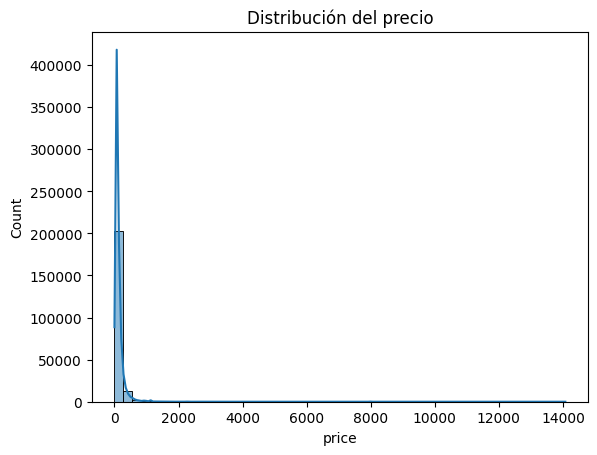

In [79]:
# Análisis de la variable precio
sns.histplot(df_all['price'], bins=50, kde=True)
plt.title('Distribución del precio')
plt.show()

<Axes: xlabel='price', ylabel='Count'>

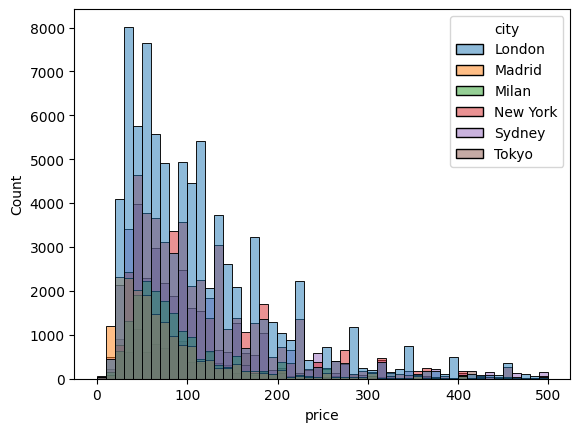

In [80]:
# Distribución de precios por ciudad
sns.histplot(data=df_all[df_all['price'] < 500], x="price", hue="city", bins=50)
# sns.histplot(data=df_all, x="price", hue="city", bins=50)

<Axes: xlabel='room_type', ylabel='price'>

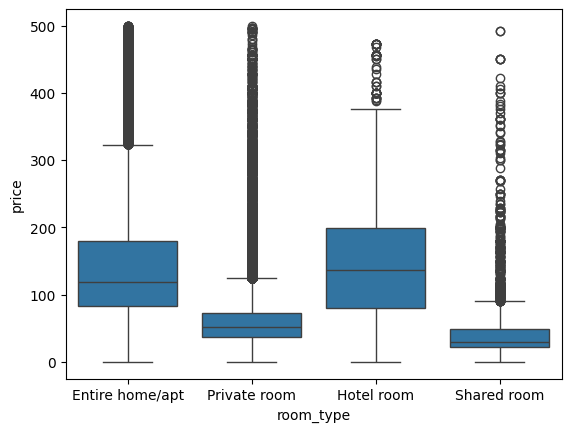

In [81]:
# Boxplot de precio por tipo de alojamiento
sns.boxplot(data=df_all[df_all['price'] < 500], x="room_type", y="price")

### Decisión con el precio
- Vamos a descartar los precios menores de 15 euros porque creemos que no son reales o son erroneos.
- Hemos consultado en internet en google el rango de precios de Airbnb en estas ciudades y hemos llegado a esta conclusión
- Los precios mayores de 1000 euros la noche aunque muy elevados consideramos que puede deberse al alquiler de casas enteras muy lujosas o céntricas o ambas cosas.

In [82]:
df_all = df_all[df_all['price'] >= 15]

### Análisis de variables numéricas

**Boxplots**

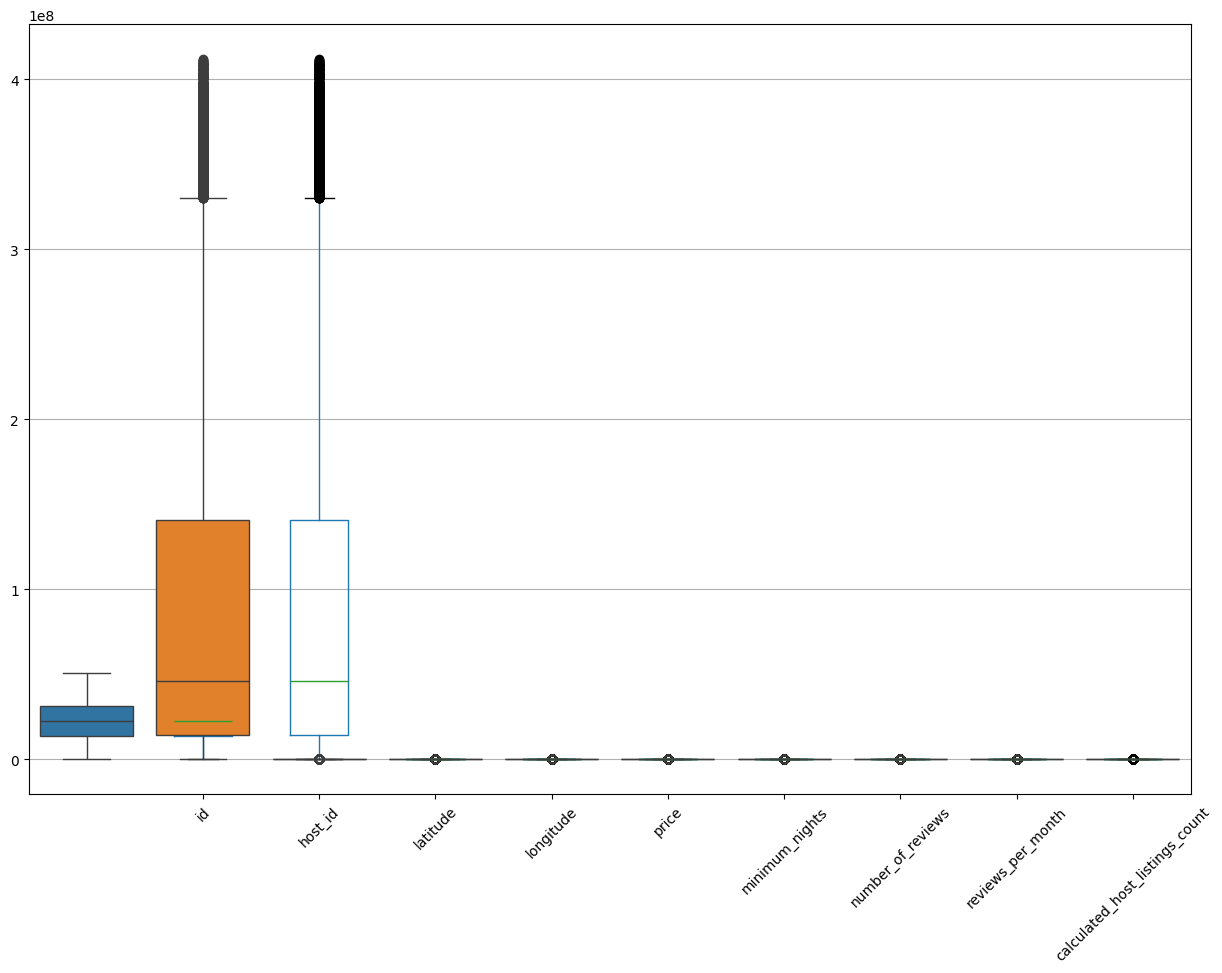

In [83]:
# Esto grafica todas las variables numéricas automáticamente
df_all.boxplot(figsize=(15, 10))
sns.boxplot(data=df_all)
plt.xticks(rotation=45)
plt.show()

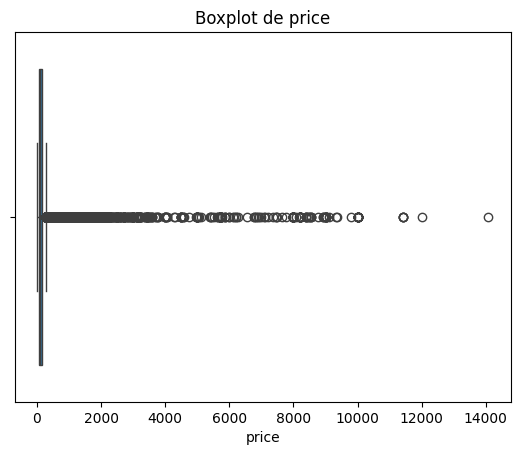

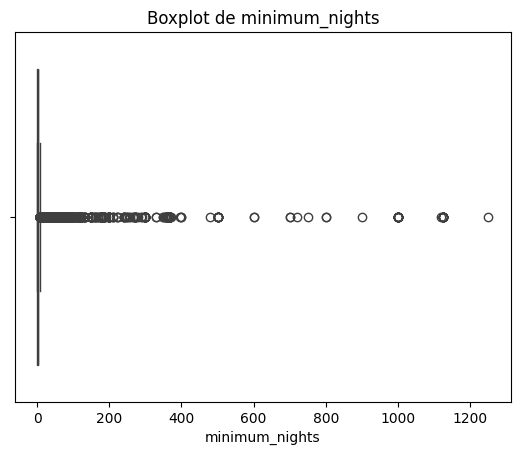

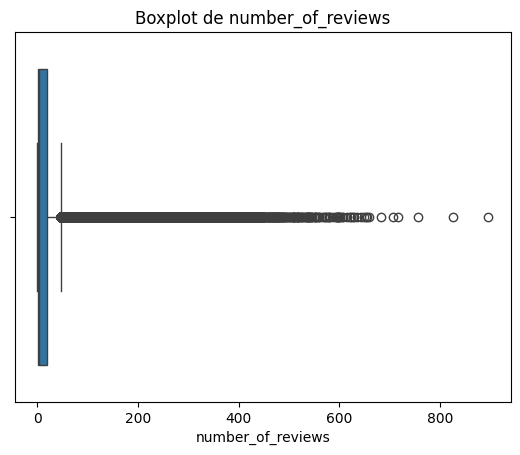

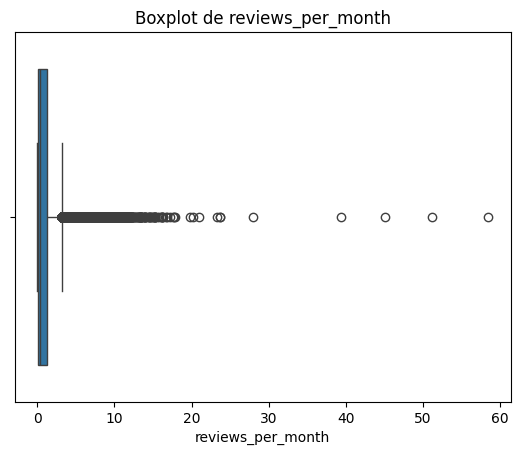

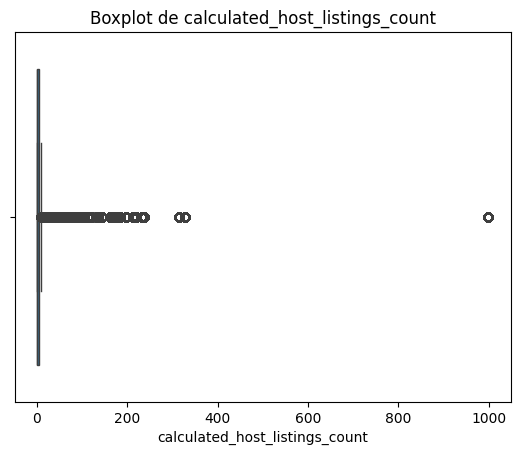

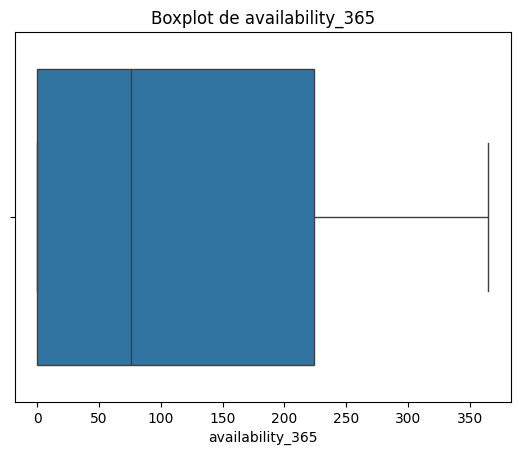

In [84]:
columns = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

for col in columns:
    plt.figure()
    sns.boxplot(x=df_all[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

**Histogramas**

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'host_id'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'last_review'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>, <Axes: >]],
      dtype=object)

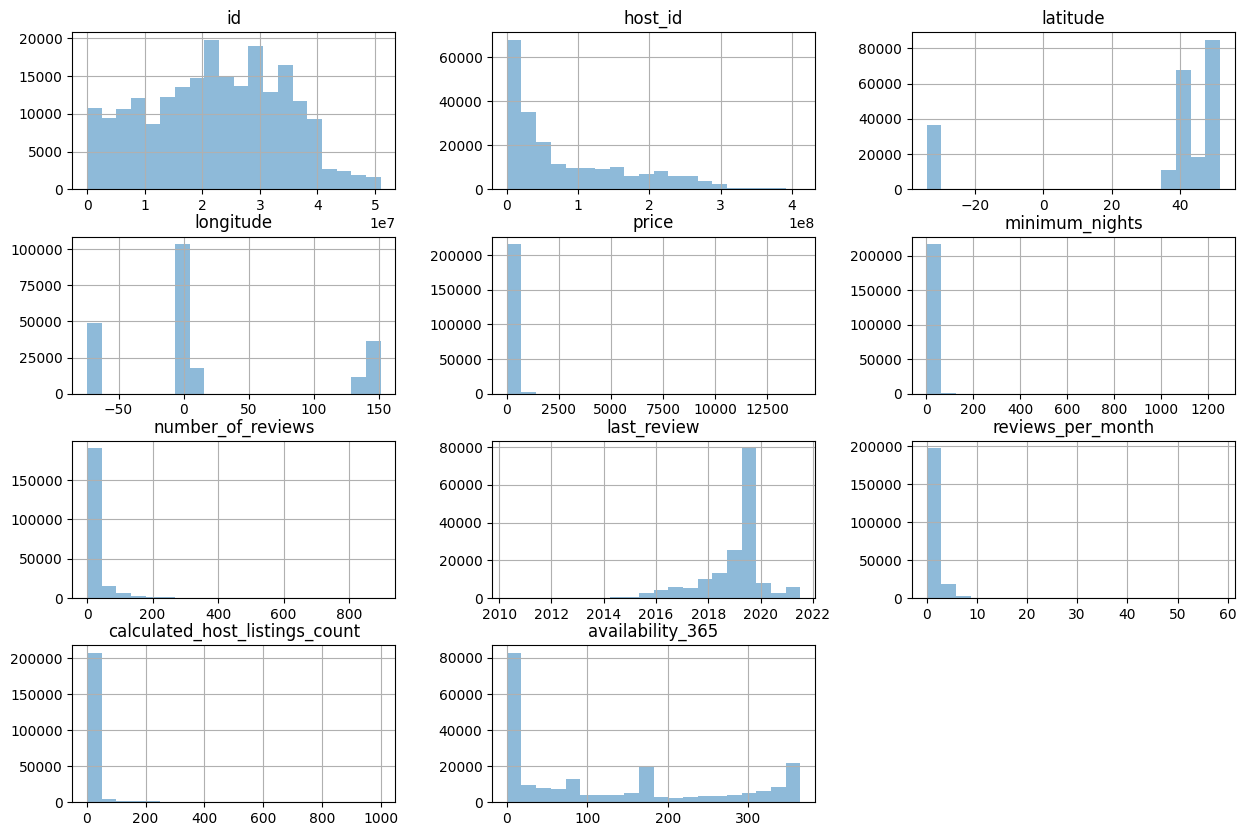

In [85]:
df_all.hist(bins=20, alpha=0.5, figsize=(15, 10))

--- 

# Sección 5

### Análisis de variables categóricas

<Axes: xlabel='room_type', ylabel='count'>

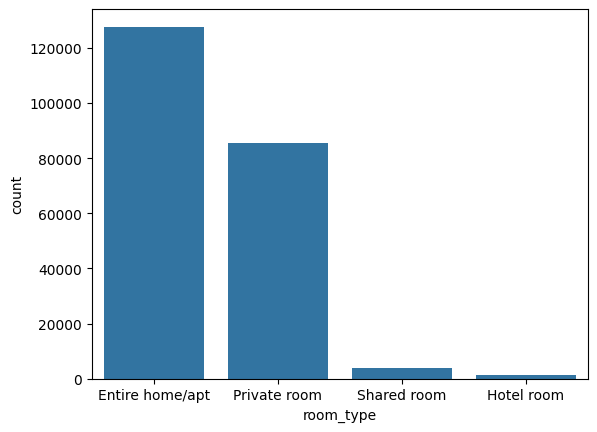

In [86]:
# Barras de tipo de alojamiento
sns.countplot(data=df_all, x="room_type", order=df_all['room_type'].value_counts().index)

<Axes: xlabel='host_type', ylabel='count'>

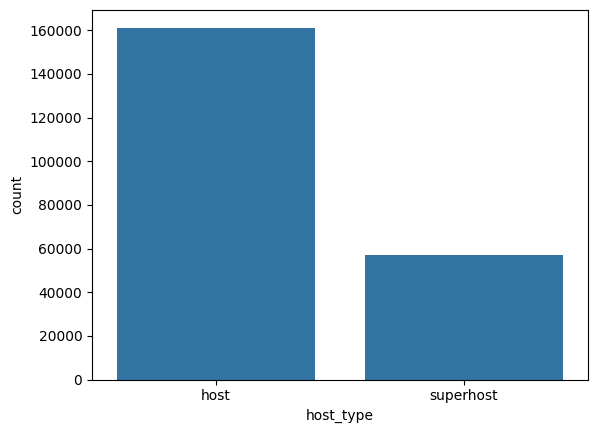

In [87]:
# Barras de tipo de host
sns.countplot(data=df_all, x="host_type", order=df_all['host_type'].value_counts().index)

In [88]:
# Conteo de variables categóricas

cat_cols = df_all.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(df_all[col].value_counts())
    print('------------------------------------------------------')

C:\Users\user\AppData\Local\Temp\ipykernel_23344\3906811746.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_all.select_dtypes(include=['object']).columns


host_name
David               1414
Veeve               1214
Michael             1089
Anna                1069
Sarah                989
                    ... 
Ami And Jun            1
虹子                     1
Terakoshi Family       1
藤城                     1
Hojun                  1
Name: count, Length: 31408, dtype: int64
------------------------------------------------------
neighbourhood_group
Unknown                  150858
Manhattan                 21636
Brooklyn                  20075
Centro                     8322
Queens                     5655
Salamanca                  1274
Chamberí                   1203
Bronx                      1088
Arganzuela                 1056
Tetuán                      771
Carabanchel                 668
Retiro                      644
Ciudad Lineal               617
Puente de Vallecas          568
Chamartín                   562
Latina                      562
Moncloa - Aravaca           533
San Blas - Canillejas       476
Staten Island          

**Precio por categoria**

In [89]:
df_all.info()

<class 'pandas.DataFrame'>
Index: 218409 entries, 0 to 11465
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              218409 non-null  int64         
 1   host_id                         218409 non-null  int64         
 2   host_name                       218409 non-null  str           
 3   neighbourhood_group             218409 non-null  str           
 4   neighbourhood                   218409 non-null  str           
 5   latitude                        218409 non-null  float64       
 6   longitude                       218409 non-null  float64       
 7   room_type                       218409 non-null  str           
 8   price                           218409 non-null  float64       
 9   minimum_nights                  218409 non-null  int64         
 10  number_of_reviews               218409 non-null  int64         
 11  last

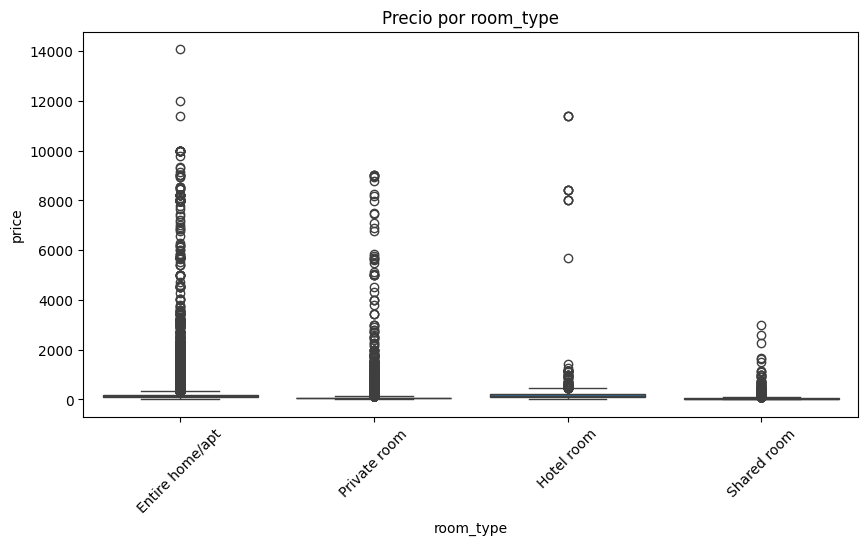

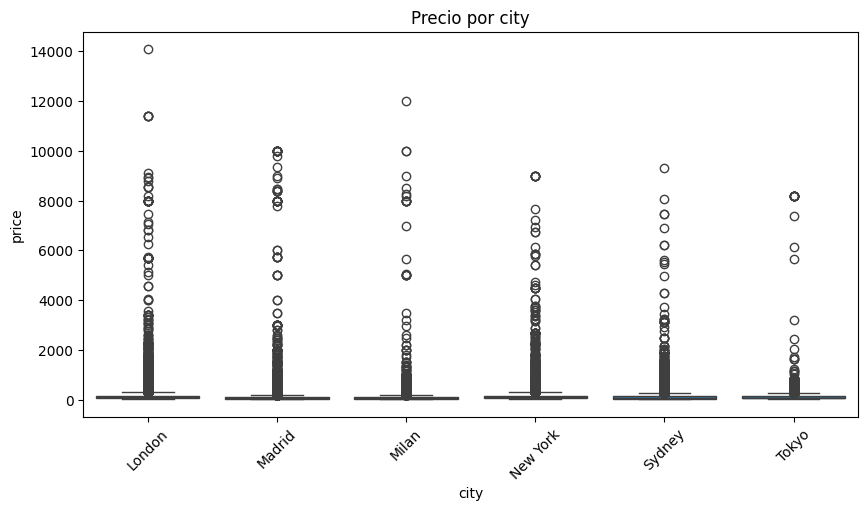

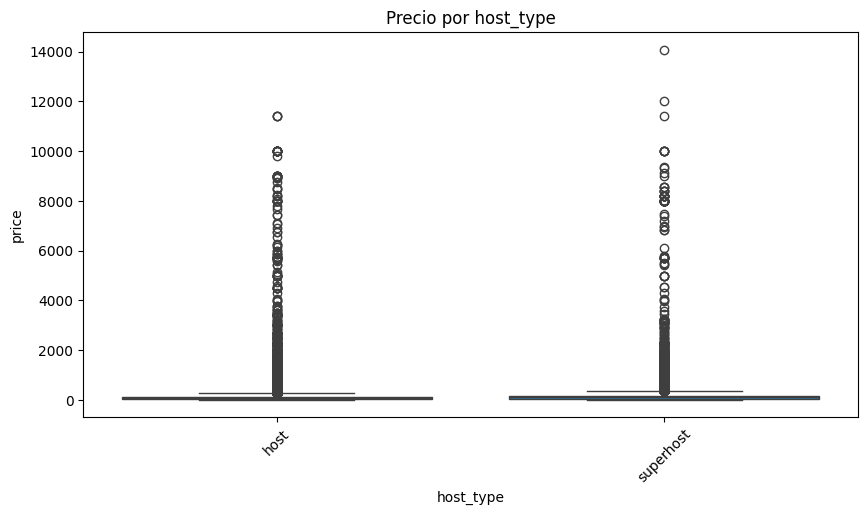

In [90]:
cat_cols = ['room_type', 'city', 'host_type']

for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df_all[col], y=df_all['price'])
    plt.xticks(rotation=45)
    plt.title(f'Precio por {col}')
    plt.show()

**Precios medios por categorias**

In [91]:
# Categoria 'neighbourhood_group'
df_all.groupby('neighbourhood_group')['price'].mean().sort_values()

neighbourhood_group
Puente de Vallecas        78.445423
Bronx                     78.973419
Villa de Vallecas         82.477273
Carabanchel               88.934132
Queens                    89.796819
Usera                     95.531008
Moratalaz                100.431373
Staten Island            103.681613
Ciudad Lineal            105.194489
Brooklyn                 112.176632
Chamartín                113.476868
Moncloa - Aravaca        115.885553
Barajas                  117.296970
Chamberí                 117.762261
Fuencarral - El Pardo    118.759197
Tetuán                   121.447471
Centro                   125.115477
Retiro                   126.541925
Unknown                  132.843205
Hortaleza                142.597701
Arganzuela               144.185606
Latina                   146.316726
Vicálvaro                151.890625
Salamanca                156.007849
Manhattan                177.507713
Villaverde               216.986207
San Blas - Canillejas    328.785714
Name: pr

In [92]:
# Categoria 'neighbourhood'
df_all.groupby('neighbourhood')['price'].mean().sort_values()

neighbourhood
STEPHENSON              15.000000
Inagi Shi               22.495000
Higashiyamato Shi       24.700000
Musashimurayama Shi     26.812000
Kunitachi Shi           32.630000
                          ...    
Hellín                 484.677419
Lucero                 505.269231
San Andrés             536.521739
Woodrow                630.630000
Fort Wadsworth         720.720000
Name: price, Length: 561, dtype: float64

In [93]:
# Categoria 'room_type'
df_all.groupby('room_type')['price'].mean().sort_values()

room_type
Shared room         56.734972
Private room        71.182149
Entire home/apt    176.210085
Hotel room         288.038414
Name: price, dtype: float64

In [94]:
# Categoria 'city'
df_all.groupby('city')['price'].mean().sort_values()

city
Milan       112.770677
Tokyo       124.340474
Sydney      129.385618
Madrid      129.772230
New York    137.729824
London      139.750462
Name: price, dtype: float64

In [95]:
# Categoria 'host_type'
df_all.groupby('host_type')['price'].mean().sort_values()

host_type
host         121.808642
superhost    167.145510
Name: price, dtype: float64

--- 

# Sección 6

### Matriz de Correlación

👉 Qué buscamos:

- Variables correlacionadas con price
- Multicolinealidad (menos importante aquí)

💡 Normalmente verás correlaciones bajas → es normal en Airbnb

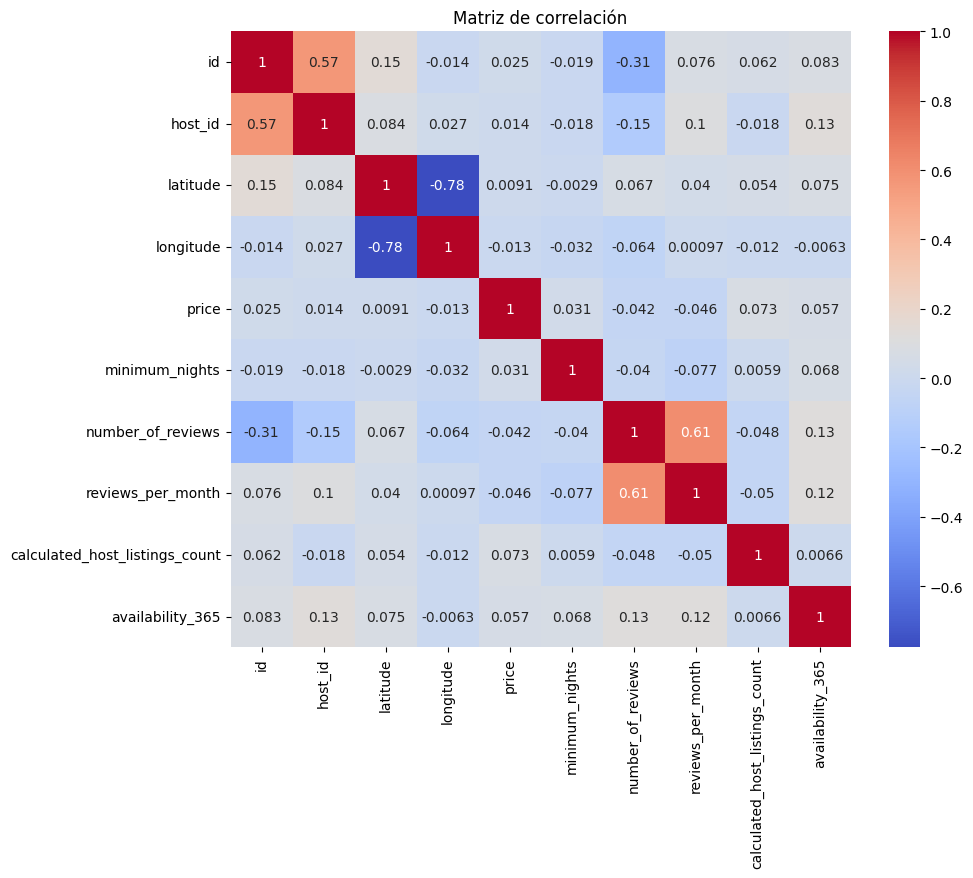

In [96]:
corr = df_all.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

--- 

# Sección 7

### Outliers

#### Revisamos el precio

<Axes: xlabel='price'>

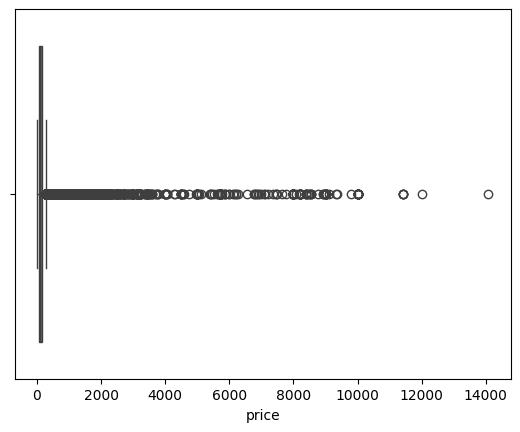

In [97]:
Q1 = df_all['price'].quantile(0.25)
Q3 = df_all['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_all[(df_all['price'] < lower) | (df_all['price'] > upper)]

sns.boxplot(x=df_all['price'])

Aunque parece que hay diferencias en el precio, lo vamos a mantener así. Las diferencias pueden ser debidas a alquileres de casas completas en lugares muy caros.

--- 

# Sección 8

### Conclusiones

- La columna *name* hemos decidido borrarla porque tiene información muy caótica e incluye caracteres en japonés y creemos que no aporta nada interesante para esta práctica.
- Las columnas *id* y *host_id* son índices de la propiedad y del propietario. Las mantenemos porque en el dashboard aportarán información.
- La columna *host_name* también aportará información en el dashboard.
- Las columnas *neighbourhood_group* y *neighbourhood* nos aportarán información de como es el precio por distrito y por barrio.
- Las columnas *latitude* y *longitude* son necesarias para situar las propiedades en un mapa y poder agrupar precios.
- Las columnas *room_type*, *city* y *host_type* nos sirven para ver precios en diferentes situaciones.
- La columna *minimum_nights* tiene muy poca influencia en el precio. Si un propietario exige un mínimo de 365 noches podría significar que es un alquiler por un año encubierto; por lo menos aquí en España según las leyes que los alquileres son de periodos de 5 años.
- La columna *number_of_reviews* y *reviews_per_month* tienen una influencia negativa en el precio. Estas columnas pueden indicar el movimiento que hay en ese alojamiento.
- La columna *last_review* guarda la fecha de la última review realizada. Los datos de estos Datasets estan entre los años 2014 y 2022. Un reseña muy antigua significa que ese alojamiento tiene poco movimiento o no ha causado ninguna impresión.
- Las columnas *calculated_host_listings_count* y *availability_365* tiene una influencia positiva pero débil en el precio.

### Guardar el fichero fusionado en raw/fusion_airbnb.csv

In [ ]:
# Guardar DataFrame a CSV
# df_all.to_csv('../data/raw/fusion_airbnb.csv', sep=';', index=False, encoding='utf-8')

In [103]:
# 2. Guardar en formato XLSX (requiere 'openpyxl')
# index=False evita guardar la columna de números de fila
df_all.to_excel('../data/raw/fusion_airbnb.xlsx', index=False, sheet_name='Hoja1')